In [1]:
%pip install -r requirements.txt --quiet
%conda install -y libgl

Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.26.0 Requires-Python >=3.9,<3.13; 1.26.1 Requires-Python >=3.9,<3.13
ERROR: Could not find a version that satisfies the requirement torch==2.5.1 (from versions: 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0, 2.12.1, 2.13.0)
ERROR: No matching distribution found for torch==2.5.1


3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: failed

Note: you may need to restart the kernel to use updated packages.



PackagesNotFoundError: The following packages are not available from current channels:

  - libgl

Current channels:

  - defaults

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.




In [1]:
from options import Options
from grid import Grid
from trajectory_generator import generate_trajectory
import torch
import numpy as np
import analysis
import os
%load_ext autoreload
import utils
import matplotlib.pyplot as plt
from plotting import network_presentation
%autoreload 2
from scipy.linalg import null_space
from tqdm import tqdm
from PathPlotter import PathPlotter

SIM_PATH = os.getcwd() + '/sim_data/'
FIG_PATH = os.getcwd() + '/figures/'

# I. Burak Model

### 1. Build and intiialize network

In [2]:
options = Options(lambda_net =  17)
options.dt= 5E-4
# options.n=128 # warning : large memory usage
options.n = 100
options.alpha=0.1

options.device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device :', options.device)
grid = Grid(options)

device : cuda
Recovering pre-computed matrix found at c:\Users\Administrator\Downloads\grid_cells_burak_fiete-main\grid_cells_burak_fiete-main/models/Wmat_beta=0.010380622837370242_gamma=0.011937716262975778_periodic=True_a=1.5_l=2_n=100.pth


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Restoring pre-computed initial state found at c:\Users\Administrator\Downloads\grid_cells_burak_fiete-main\grid_cells_burak_fiete-main/models/s0_beta=0.010380622837370242_gamma=0.011937716262975778_periodic=True_a=1.5_l=2_n=100_tau=0.01_alpha=0.1_tiling=deterministic_device=cuda_solver=euler_dt=0.0005.pth


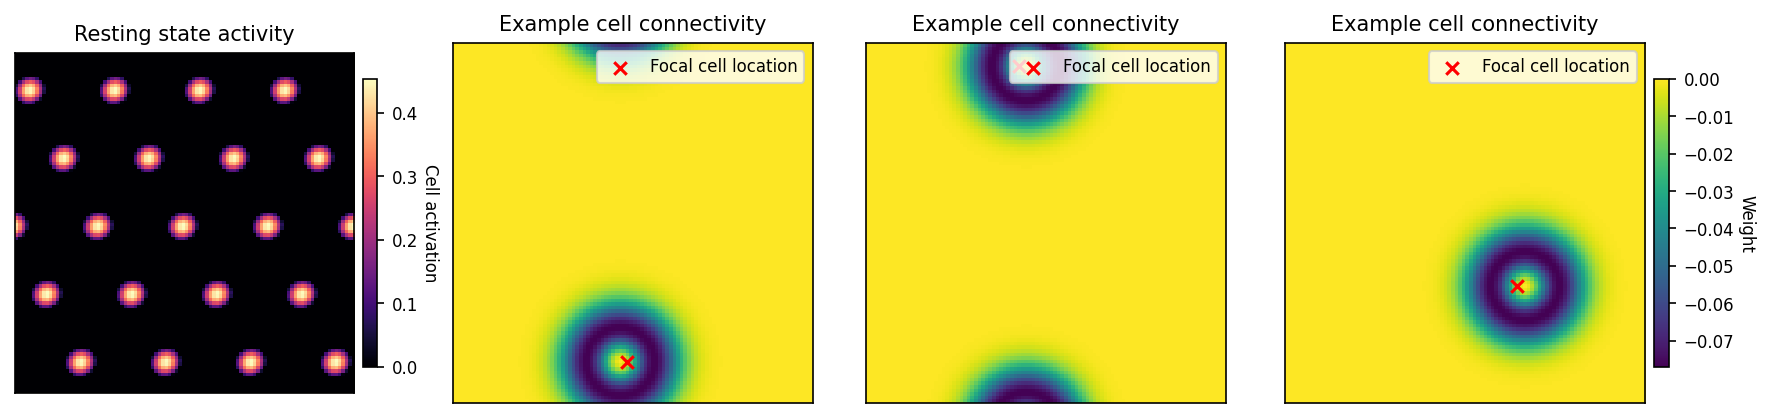

In [4]:
network_presentation(grid, show=False)
plt.savefig(FIG_PATH+"network_presentation.png", transparent=True)

### 2. Record pattern formation and dynamics

In [5]:
# uncomment to record pattern formation

"""
T = 0.02
dt = 1e-4
num_steps = int(T/dt)
v = np.zeros((num_steps, 2))
S = grid.simulate(v, s_0 = 0.001*np.random.randn(options.n**2)).squeeze()
plotting.plot_10_frames(S, dt)
plotting.rec_movie(S, fpath=FIG_PATH + 'pattern_formation.mp4', dt=dt, speed_ratio = 1/500)
"""

"\nT = 0.02\ndt = 1e-4\nnum_steps = int(T/dt)\nv = np.zeros((num_steps, 2))\nS = grid.simulate(v, s_0 = 0.001*np.random.randn(options.n**2)).squeeze()\nplotting.plot_10_frames(S, dt)\nplotting.rec_movie(S, fpath=FIG_PATH + 'pattern_formation.mp4', dt=dt, speed_ratio = 1/500)\n"

In [10]:
# uncomment to record pattern moving
'''
T = 0.5
dt = 1e-4
num_steps = int(T/dt)
v = np.zeros((num_steps, 2))
v[:num_steps//2, 0] = 1
v[num_steps//2:, 1] = 1

S = grid.simulate(v).squeeze()

labels = [rf'$v_x =${v[k, 0]}, $v_y=$ {v[k, 1]}' for k in range(len(v))]
plotting.rec_movie(S, fpath=FIG_PATH + 'pattern_moving.mp4', dt=dt, speed_ratio = 1/20, plot_blob_centers=True, frame_labels=labels)
'''

"\nT = 0.5\ndt = 1e-4\nnum_steps = int(T/dt)\nv = np.zeros((num_steps, 2))\nv[:num_steps//2, 0] = 1\nv[num_steps//2:, 1] = 1\n\nS = grid.simulate(v).squeeze()\n\nlabels = [rf'$v_x =${v[k, 0]}, $v_y=$ {v[k, 1]}' for k in range(len(v))]\nplotting.rec_movie(S, fpath=FIG_PATH + 'pattern_moving.mp4', dt=dt, speed_ratio = 1/20, plot_blob_centers=True, frame_labels=labels)\n"

### 3. Integrate random trajectory

In [6]:
# generate a trajectory 
box_width = box_height = 2.2 # m 
T = 10 # s
dt = grid.options.dt
seq_len = int(T/dt)

traj = generate_trajectory(box_width, box_height, seq_len, dt=dt, load=True, save=True, batch_size = 1, silent=False)
input_v = traj['input_v'].squeeze()
pos = np.stack([traj['target_x'].squeeze(), traj['target_y'].squeeze()], 1)

100%|██████████| 20001/20001 [00:04<00:00, 4676.49it/s]


In [ ]:
# Baseline

from grid_cells import Module
from phases_to_location import phasesToLocation1DProgressive

import numpy as np


class RunTrial:
    def __init__(self, NUM_OF_MODS=10, NUM_SPATIAL_PHASES=20, NUM_NEURONS_P_PHASE=20,
                 speed_noise_amplitude=0.05, headdir_noise_amplitude=0.025,
                 speed_tau=2.0, dir_tau=1.0,
                 ts=0.001, simlen=20000, deltahead=2.4,
                 spacing_min=25, scaling=1.65, bio_noise=False,
                 bio_speed_amp=0.05, bio_dir_amp=0.025, bio_speed_tau=2.0, bio_dir_tau=1.0,
                 speed=np.empty(0), head_dir=np.empty(0), og_position_x=np.empty(0), og_position_y=np.empty(0),
                 seed=67):
        self.NUM_MODULES = NUM_OF_MODS
        self.NUM_SPATIAL_PHASES = NUM_SPATIAL_PHASES
        self.NUM_NEURONS_P_PHASE = NUM_NEURONS_P_PHASE

        self.ts = ts  # in seconds, timestep
        self.simlen = simlen  # of timesteps, simulation length
        self.deltahead = deltahead  # in degrees

        self.speed = np.zeros(1)  # cm / s
        self.head_dir = np.zeros(1)  # radians
        self.final_og_position = np.zeros(2)  # cm

        '''
            documentation for below from grid_cells.py:

            speed_noise_amplitude: noise strength for fractional speed error. Default 0.05
            dir_noise_amplitude: noise strength for radian head direction error. Default 0.025
            speed_tau: relaxation constant for speed OU process. Default 2.0
            dir_tau: relaxation constant for head direction OU process. Default 1.0
        '''
        self.speed_noise_amplitude = speed_noise_amplitude
        self.dir_noise_amplitude = headdir_noise_amplitude
        self.speed_tau = speed_tau  # s
        self.dir_tau = dir_tau  # s

        self.bio_noise = bio_noise  # if there is biological noise (each module receives velocity w/ a different error)
        self.bio_speed_amp = bio_speed_amp
        self.bio_speed_tau = bio_speed_tau
        self.bio_dir_amp = bio_dir_amp
        self.bio_dir_tau = bio_dir_tau

        self.speed = speed
        self.head_dir = head_dir
        self.og_position_x = og_position_x
        self.og_position_y = og_position_y

        self.spacing_min = spacing_min  # cm, grid cell assembly
        self.scaling = scaling  # ratio, grid cell assembly

        self.seed = seed

        self.x_trig_dist = 0.0
        self.y_trig_dist = 0.0

        self.rng = np.random.default_rng(seed)

    def hex_basis_to_cart(self, u, v):
        x = u + 0.5 * v
        y = np.sqrt(3) / 2 * v
        return x, y

    def assembly_grid_cells(self):
        ''' generate grid cell structure of NUM_MODULES modules,
        each with 20 spatial phases, 20 neurons per phase'''
        self.s_is = [self.spacing_min * (self.scaling ** i) for i in range(self.NUM_MODULES)]
        self.modules = [Module(spacing=self.s_is[i],
                               bio_noise=self.bio_noise,
                               speed_tau=self.bio_speed_tau,
                               speed_amp=self.bio_speed_amp,
                               dir_tau=self.bio_dir_tau,
                               dir_amp=self.bio_dir_amp,
                               ) for i in range(self.NUM_MODULES)]

    def run_trial(self, error_freq: int = -1):
        """
        Simulates the grid cell phases changing by velocity of the mouse

        :param int error_freq:
            -1 if you just want to call get_location() at the end.
            otherwise frequency per time step that get_location()
            is called to determine time-based error.
            will call get_location() at end no matter what.
            e.g., 1 for calling get_location every timestep.
        """
        speed_noise = 0.0
        dir_noise = 0.0

        if (error_freq == -1):
            self.simulated_locations = np.zeros((1, 3))
        else:
            _len_for_sim_locations = int(np.floor(self.simlen / error_freq))
            if ((self.simlen - 1) % error_freq != 0): _len_for_sim_locations += 1
            self.simulated_locations = np.zeros((_len_for_sim_locations, 3))

        for t in range(self.simlen):
            # simulate velocity (with error).
            speed_noise += self.OU_increment(speed_noise, self.speed_tau, self.speed_noise_amplitude, self.ts)
            dir_noise += self.OU_increment(dir_noise, self.dir_tau, self.dir_noise_amplitude, self.ts)

            t_speed = max(0.0, self.speed[t] * (1 + speed_noise))
            t_headdir = self.head_dir[t] + dir_noise

            # update phase
            for i in range(self.NUM_MODULES):
                self.modules[i].update(t_speed, t_headdir, self.ts)

            # see current sim location & error
            if ((error_freq != -1 and t % error_freq == 0)):
                self.simulated_locations[int(t / error_freq)][0] = t
                self.simulated_locations[int(t / error_freq)][1:] = self.get_location()
            elif (t == self.simlen - 1):
                self.simulated_locations[-1][0] = t
                self.simulated_locations[-1][1:] = self.get_location()

        self.final_simulated_position = self.get_location()
        return self.simulated_locations[:]

    def get_location(self):
        phases = np.array([self.modules[i].phase for i in range(self.NUM_MODULES)])
        data_x = np.zeros((self.NUM_MODULES, 2))
        data_x[:, 0] = self.s_is
        data_x[:, 1] = phases[:, 0]
        self.x_trig_dist = phasesToLocation1DProgressive(data_x, self.x_trig_dist)

        data_y = np.zeros((self.NUM_MODULES, 2))
        data_y[:, 0] = self.s_is
        data_y[:, 1] = phases[:, 1]
        self.y_trig_dist = phasesToLocation1DProgressive(data_y, self.y_trig_dist)
        return self.hex_basis_to_cart(self.x_trig_dist, self.y_trig_dist)

    def OU_increment(self, noise, tau, amp, dt):
        """
            Update OU process.

            :param float noise: current process value.
            :param float tau: relaxation time in seconds.
            :param float amp: scale of noise.
            :param float dt: time step length in seconds.
            :return update for OU process:
            :rtype float:
        """
        return -noise * dt / tau + self.rng.normal(loc=0.0, scale=amp * np.sqrt(dt))

trial = RunTrial(speed=traj["true_speed"][0], head_dir=traj["true_hd"][0],
                 og_position_x=traj["true_x"][0], og_position_y=traj["true_y"][0],
                 simlen=T*1000)

# pos_pred_baseline = np.zeros((10000, 2))
trial.assembly_grid_cells()
pos_pred_baseline = trial.run_trial()


In [10]:
fname = f"example_sim_T={T}_dt={dt}_{grid.grid_id}.pth"
grid.save_sim = True
S = grid.simulate(input_v, sim_id = fname, silent=False, load=True) # set load = false to restart a new sim from scratch

# downsample if needed for faster analysis 
new_dt = 1E-3
S = utils.downsample(S, new_dt=new_dt, old_dt = dt, axis=1)
pos = utils.downsample(pos, new_dt=new_dt, old_dt = dt)

pos_pred_CAN, prop_factor, r2 = analysis.model_prediction(S, pos, verb = True)
pos_pred_CAN = np.vstack((pos[0], pos_pred_CAN))

Simulating with Euler method


100%|██████████| 19999/19999 [02:25<00:00, 137.03it/s]


saving simulation at c:\Users\Administrator\Downloads\grid_cells_burak_fiete-main\grid_cells_burak_fiete-main/sim_data/example_sim_T=10_dt=0.0005_beta=0.010380622837370242_gamma=0.011937716262975778_periodic=True_a=1.5_l=2_n=100_tau=0.01_alpha=0.1_tiling=deterministic_device=cuda_solver=euler_dt=0.0005.pth
labeling blobs


100%|██████████| 10000/10000 [00:02<00:00, 3590.97it/s]


detected less than 27 blobs per frame
computing blob centers


  0%|          | 0/10000 [00:00<?, ?it/s]c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\ndimage\_measurements.py:1535: RuntimeWarning: invalid value encountered in divide
  results = [sum(input * grids[dir].astype(float), labels, index) / normalizer
100%|██████████| 10000/10000 [00:10<00:00, 974.90it/s]


found 3 best blob jumps : interpolating speed between them
best_center shape: (10000, 2)
best_center first: [[49.         50.41025641]
 [49.         50.41025641]
 [49.         50.41025641]
 [49.         50.41025641]
 [49.         50.41025641]]
predicted_pos min: [-62.86152289 -35.01114468]
predicted_pos max: [24.15454545 59.56236264]
predicted_pos std: [23.02793035 27.81206579]
true_pos min: [-1.07039344 -1.07073326]
true_pos max: [1.07031085 1.07020251]
true_pos std: [0.57077142 0.63540707]
Estimated prediction to truth size ratio = -0.0247, R2=0.995


[[ 0.42096866 -1.7495509 ]]


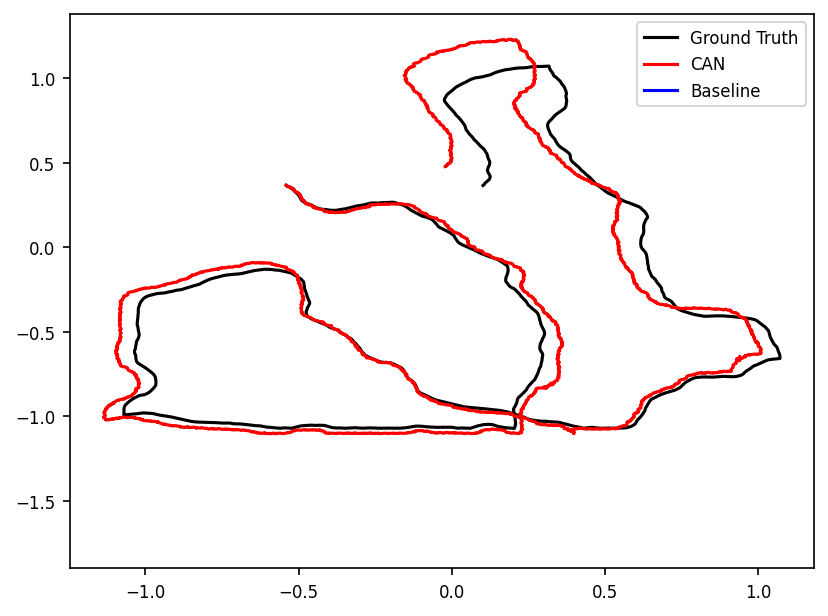

(10000, 2)
(10000, 2)
(1, 2)


In [17]:
# _ = plotting.compare_model_prediction(pos_pred_CAN, pos_pred_baseline, pos, box_width = box_width, box_height = box_height)
plotter = PathPlotter()

print(pos_pred_baseline)

plotter.paths([pos, pos_pred_CAN, pos_pred_baseline], ["black", "red", "blue"], ["Ground Truth", "CAN", "Baseline"])
for arr in [pos, pos_pred_CAN, pos_pred_baseline]:
    print(arr.shape)